# EDA for `foody_combined_data_final.csv`

This notebook quickly summarizes key statistics:
1. Dataset Overview
2. Descriptive Statistics
3. Top 20 Districts
4. Top 20 Cuisines
5. Top 20 Categories
6. Target Audience Distribution
7. Price Distribution
8. TotalView Distribution
9. Price vs TotalView Relationship
10. Rating Correlation
11. Average Rating Distribution
12. Delivery and Table Reservation
13. Operating Schedule
14. Sentiment Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
pd.set_option('display.max_colwidth', 120)

In [ ]:
df = pd.read_csv('dataset/foody_combined_data_final.csv')
display(df.head(5))

,RestaurantID,Name,Address,District,Area,PriceMin,PriceMax,MetaKeywords,Cuisines,LstTargetAudience,LstCategory,RestaurantUrl,Vị trí,Giá cả,Chất lượng,Phục vụ,Không gian,Excellent,Good,Average,Bad,TotalView,TotalFavourite,TotalCheckins,Giao tận nơi,Đặt bàn,Chủ nhật,Thứ hai,Thứ ba,Thứ tư,Thứ năm,Thứ sáu,Thứ bảy,Ngày nghỉ
0,1.000026e+09,Con Cú Có Cacao - Chuyên Trà Sữa Từ Sữa Tươi - Đoàn Văn Bơ,"114 Chung Cư Đoàn Văn Bơ (Hẻm 83 Hoàng Diệu), P. 12",Quận 4,NaN,0.0,0.0,"Trà sữa, Trà Chanh",Món Việt,Sinh viên || Cặp đôi || Nhóm hội,Ăn vặt/vỉa hè || Café/Dessert,ho-chi-minh/con-cu-co-cacao-chuyen-tra-sua-tu-sua-tuoi-doan-van-bo.hvg0tn,0.0,0.0,0.0,0.0,0.0,0,0,0,0,12.0,0.0,0.0,1,0,"('16:30', '23:59')","('16:30', '23:59')","('16:30', '23:59')","('16:30', '23:59')","('16:30', '23:59')","('16:30', '23:59')","('16:30', '23:59')",NaN
1,2.144950e+05,Trứng Gà Nướng - Thanh Đa,Thanh Đa,Quận Bình Thạnh,Thanh Đa - Bình Quới,6000.0,6000.0,"trứng gà nướng quận bình thạnh, trứng gà nướng đường thanh đa, hột gà nướng quận bình thạnh, hột gà nướng đường than...",Món Việt,Sinh viên || Cặp đôi || Gia đình || Nhóm hội,Ăn vặt/vỉa hè,ho-chi-minh/trung-ga-nuong-thanh-da,0.0,0.0,0.0,0.0,0.0,0,0,0,0,607.0,1.0,1.0,0,0,"('17:00', '00:00')","('17:00', '00:00')","('17:00', '00:00')","('17:00', '00:00')","('17:00', '00:00')","('17:00', '00:00')","('17:00', '00:00')",NaN
2,7.588870e+05,Mr Thịnh - Khoai Lắc & Gà Rán - Ngô Quyền,114 Ngô Quyền,Quận 10,Sân Thống Nhất,10000.0,20000.0,"khoai lắc đường ngô quyền, khoai lắc quận 10, ăn vặt đường ngô quyền, ăn vặt quận 10, gà rán đường ngô quyền, gà rán...",Món Việt,Sinh viên || Gia đình || Nhóm hội,Ăn vặt/vỉa hè,ho-chi-minh/mr-thinh-khoai-lac-ga-ran-ngo-quyen,0.0,0.0,0.0,0.0,0.0,0,0,0,0,321.0,0.0,0.0,0,0,"('07:00', '22:00')","('07:00', '22:00')","('07:00', '22:00')","('07:00', '22:00')","('07:00', '22:00')","('07:00', '22:00')","('07:00', '22:00')",NaN
3,2.569930e+05,Quán Ăn Hà Nội - Bún Đậu & Bún Cá,"197 Nguyễn Văn Công, P. 3",Quận Gò Vấp,Ngã 5 Nguyễn Thái Sơn,25000.0,30000.0,"quán ăn hà nội, hà nội quán, bún đậu, bún đậu hà nội, bún cá hà nội, bún mọc hà nội, đặc sản hà nội, quán ăn gò vấp,...",Món Bắc,Gia đình || Nhóm hội || Giới văn phòng,Quán ăn,ho-chi-minh/quan-an-ha-noi-bun-dau-bun-ca,0.0,0.0,0.0,0.0,0.0,0,0,0,0,201.0,2.0,0.0,1,0,"('06:00', '22:00')","('06:00', '22:00')","('06:00', '22:00')","('06:00', '22:00')","('06:00', '22:00')","('06:00', '22:00')","('06:00', '22:00')",NaN
4,9.413480e+05,Mì Ngũ Trảo,"66 Lãnh Binh Thăng, P. 13",Quận 11,Phú Thọ,30000.0,45000.0,"mì lãnh bình thăng, mỳ lãnh bình thăng, mì ngon lãnh bình thăng, mỳ ngon lãnh bình thăng, mì bình dân lãnh bình thăn...",Món Việt,Sinh viên || Gia đình || Nhóm hội || Giới văn phòng,Quán ăn,ho-chi-minh/mi-ngu-trao,0.0,0.0,0.0,0.0,0.0,0,0,0,0,407.0,5.0,0.0,0,0,"('09:00', '21:00')","('09:00', '21:00')","('09:00', '21:00')","('09:00', '21:00')","('09:00', '21:00')","('09:00', '21:00')","('09:00', '21:00')",NaN


## 1. Load the dataset and check basic info, shape, missing values, duplicates, and unique values

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 107365, Columns: 34


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107365 entries, 0 to 107364
Data columns (total 34 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   RestaurantID       107365 non-null  float64
 1   Name               107365 non-null  object 
 2   Address            107363 non-null  object 
 3   District           107365 non-null  object 
 4   Area               71642 non-null   object 
 5   PriceMin           107365 non-null  float64
 6   PriceMax           107365 non-null  float64
 7   MetaKeywords       103594 non-null  object 
 8   Cuisines           91204 non-null   object 
 9   LstTargetAudience  83408 non-null   object 
 10  LstCategory        107365 non-null  object 
 11  RestaurantUrl      107365 non-null  object 
 12  Vị trí             107365 non-null  float64
 13  Giá cả             107365 non-null  float64
 14  Chất lượng         107365 non-null  float64
 15  Phục vụ            107365 non-null  float64
 16  Kh

In [5]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
}).sort_values(by='missing_count', ascending=False)

display(missing)

,missing_count,missing_percent
Ngày nghỉ,104874,97.68
Area,35723,33.27
LstTargetAudience,23957,22.31
Cuisines,16161,15.05
TotalFavourite,12296,11.45
TotalCheckins,12296,11.45
TotalView,12296,11.45
MetaKeywords,3771,3.51
Address,2,0.00
RestaurantID,0,0.00


In [6]:
# Normalize text for duplicate checking
def normalize_text_series(series):
    return (
        series.astype('string')
        .str.strip()
        .str.lower()
        .replace({'': pd.NA, 'nan': pd.NA, 'none': pd.NA})
    )

def duplicate_summary(df, column):
    normalized = normalize_text_series(df[column])
    
    dup_mask = normalized.notna() & normalized.duplicated(keep=False)
    dup_count = int(dup_mask.sum())
    unique_dup_count = int(normalized[dup_mask].nunique())

    print(f'\nCount: {column}')
    print(f'- Rows with duplicates: {dup_count}')
    print(f'- Unique duplicate values: {unique_dup_count}')

    if dup_count > 0:
        sample = (
            df.loc[dup_mask, [column]]
            .assign(_normalized=normalized[dup_mask].values)
            .groupby('_normalized', dropna=True)
            .size()
            .sort_values(ascending=False)
            .head(10)
        )
        display(sample.to_frame('count'))


# Check duplicates for important columns
duplicate_summary(df, 'RestaurantID')
duplicate_summary(df, 'Name')
duplicate_summary(df, 'RestaurantUrl')


Count: RestaurantID
- Rows with duplicates: 0
- Unique duplicate values: 0

Count: Name
- Rows with duplicates: 999
- Unique duplicate values: 431


,count
_normalized,
cơm bình dân,11
bánh mì nướng muối ớt,10
hủ tiếu nam vang,8
góc phố cafe,8
home coffee,8
bún chả hà nội,6
cháo ếch singapore,6
cơm tấm đêm,5
napoli coffee,5



Count: RestaurantUrl
- Rows with duplicates: 0
- Unique duplicate values: 0


## 2. Descriptive statistics

In [7]:
print('\nDESCRIPTIVE STATISTICS:')
display(df.describe(include='all').transpose())


DESCRIPTIVE STATISTICS:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RestaurantID,107365.0,NaN,NaN,NaN,149127008.746724,355295464.915846,7.0,716907.0,915383.0,1128214.0,1000097321.0
Name,107365,106827,Cơm Bình Dân,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,107363,95053,"120 Đường Số 8, P. 11",113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,107365,26,Tp. Thủ Đức,9009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,71642,261,Bình Trị Đông,1143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PriceMin,107365.0,NaN,NaN,NaN,22252.094249,94442.515197,0.0,5000.0,15000.0,25000.0,20000000.0
PriceMax,107365.0,NaN,NaN,NaN,81717.526764,286658.420921,0.0,15000.0,30000.0,60000.0,27000000.0
MetaKeywords,103594,96953,Trà sữa,245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cuisines,91204,813,Món Việt,66995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LstTargetAudience,83408,196,Gia đình || Nhóm hội || Giới văn phòng,23961,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
def split_multivalue_column(series):
    cleaned = (
        series.dropna()
        .astype('string')
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    exploded = cleaned.str.split(r'\s*\|\|\s*', regex=True).explode()
    exploded = exploded.astype('string').str.strip()
    exploded = exploded[(exploded.notna()) & (exploded != '')]
    return exploded

def add_value_labels(ax, fmt='{:.0f}'):
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 4),
            textcoords='offset points'
        )


## 3. Top 20 districts by number of restaurants

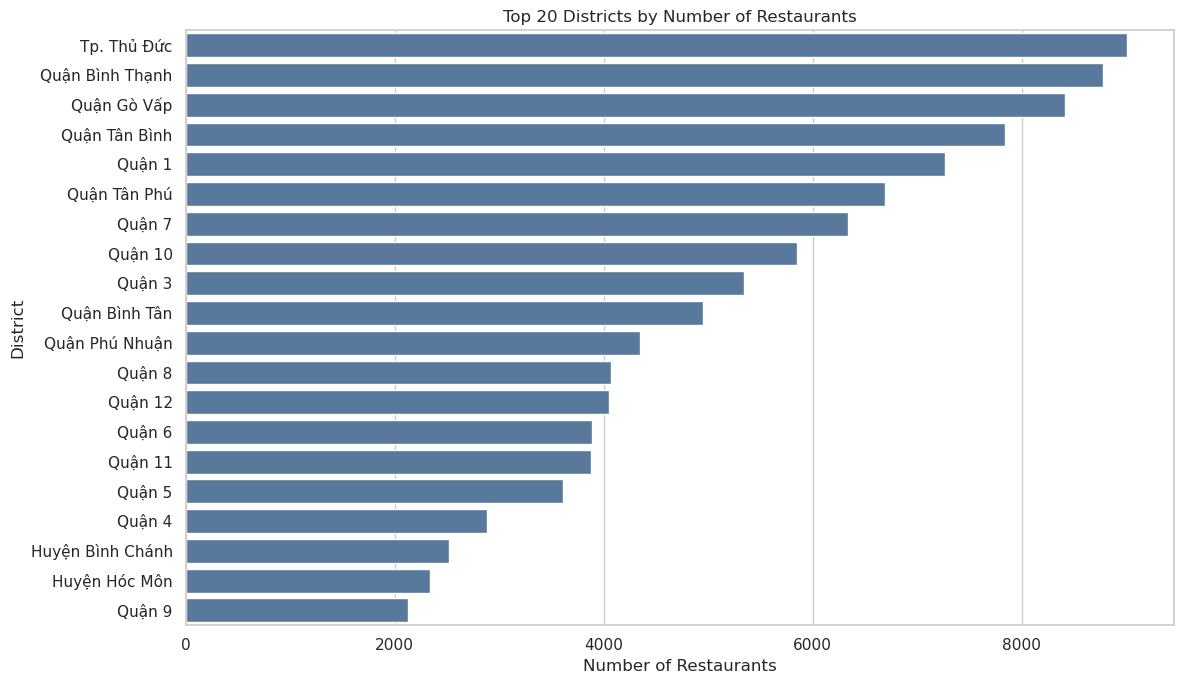

In [9]:
district_counts = df['District'].astype('string').str.strip().value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=district_counts.values, y=district_counts.index, color='#4e79a7')
plt.title('Top 20 Districts by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('District')
plt.tight_layout()
plt.show()


## 4. Top 20 Cuisines by number of restaurants

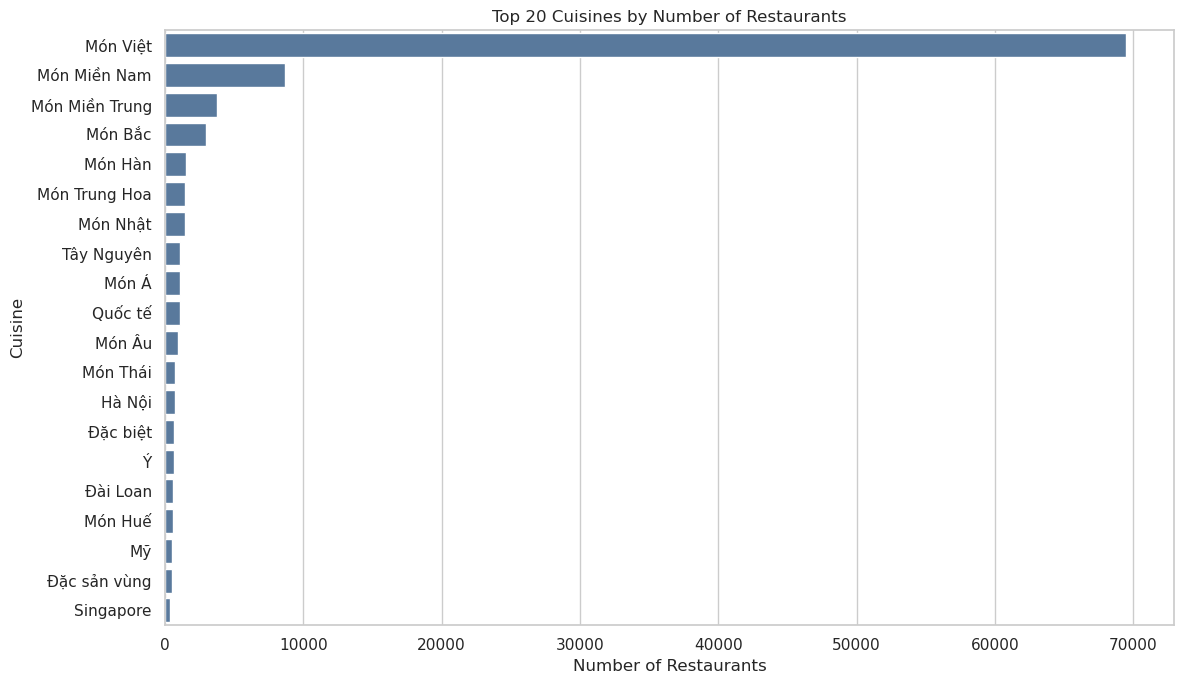

In [10]:
cuisine_exploded = split_multivalue_column(df['Cuisines'])
cuisine_counts = cuisine_exploded.value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, color='#4e79a7')
plt.title('Top 20 Cuisines by Number of Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()


## 5. Top 20 Categories by number of restaurants

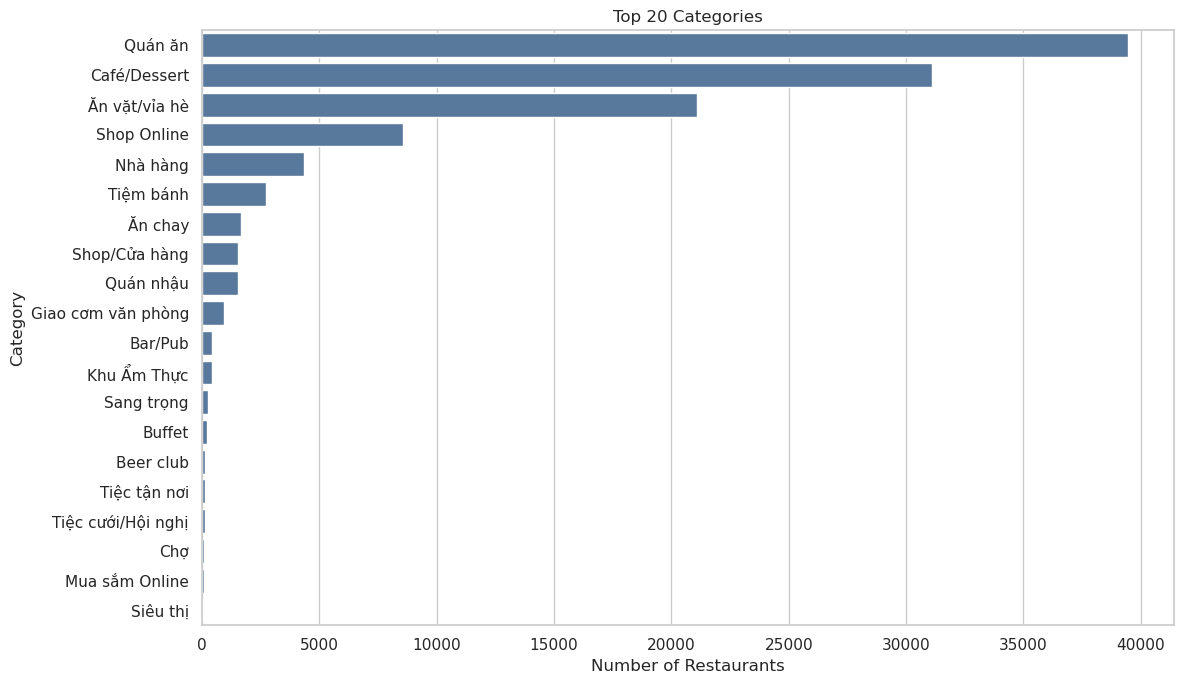

In [11]:
category_exploded = split_multivalue_column(df['LstCategory'])
category_counts = category_exploded.value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=category_counts.values, y=category_counts.index, color='#4e79a7')
plt.title('Top 20 Categories')
plt.xlabel('Number of Restaurants')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## 6. Target Audience distribution

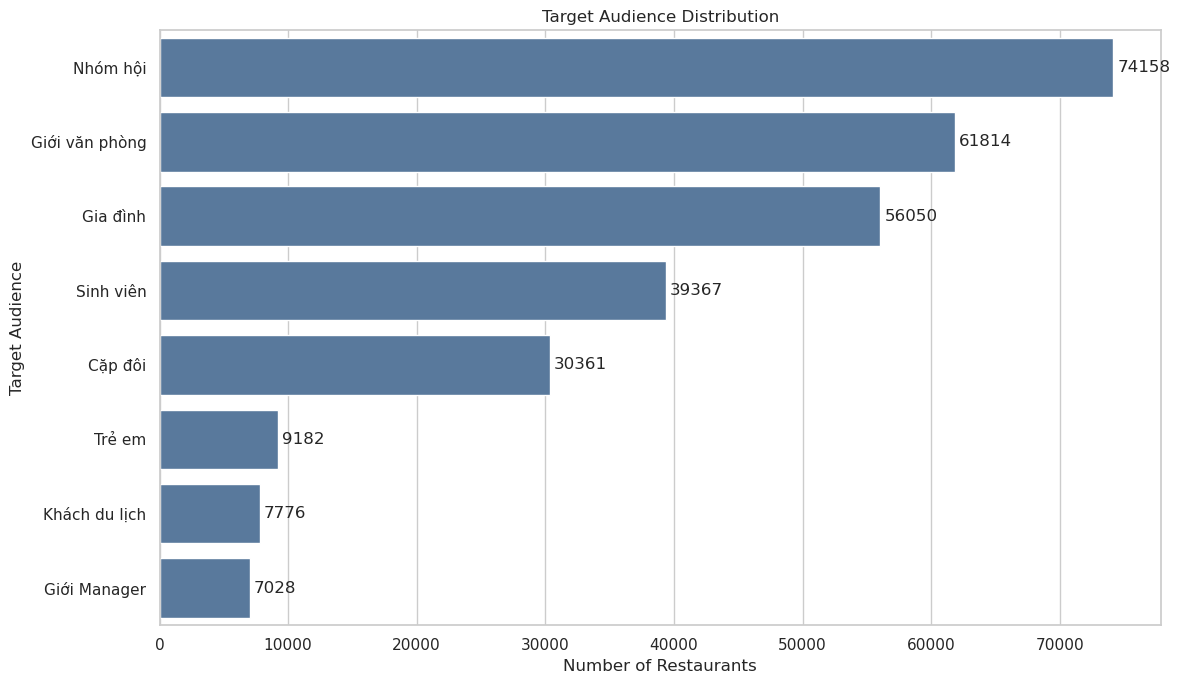

In [12]:
def add_value_label(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)

audience_exploded = split_multivalue_column(df['LstTargetAudience'])
audience_counts = audience_exploded.value_counts()

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=audience_counts.values,
    y=audience_counts.index,
    color='#4e79a7'
)

add_value_label(ax)

plt.title('Target Audience Distribution')
plt.xlabel('Number of Restaurants')
plt.ylabel('Target Audience')

plt.tight_layout()
plt.show()


## 7. Price distribution

=== PRICE SUMMARY ===


,non_null,zero_count,mean,median,min,max
PriceMin,107365,23553,22252.094249,15000.0,0.0,20000000.0
PriceMax,107365,23589,81717.526764,30000.0,0.0,27000000.0
Price Average,107365,23542,51984.810506,25000.0,0.0,13529500.0
Price Average No Zero,83823,0,66595.006263,30000.0,16.0,13529500.0


,PriceMin,PriceMax,Price Average,Price Average No Zero
count,1.073650e+05,1.073650e+05,1.073650e+05,8.382300e+04
mean,2.225209e+04,8.171753e+04,5.198481e+04,6.659501e+04
std,9.444252e+04,2.866584e+05,1.702918e+05,1.901875e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01
25%,5.000000e+03,1.500000e+04,1.250000e+04,2.100000e+04
50%,1.500000e+04,3.000000e+04,2.500000e+04,3.000000e+04
75%,2.500000e+04,6.000000e+04,4.250000e+04,5.500000e+04
max,2.000000e+07,2.700000e+07,1.352950e+07,1.352950e+07


99th percentile: 512500.0
Rows after removing zero: 83823
Rows after removing outliers: 82988


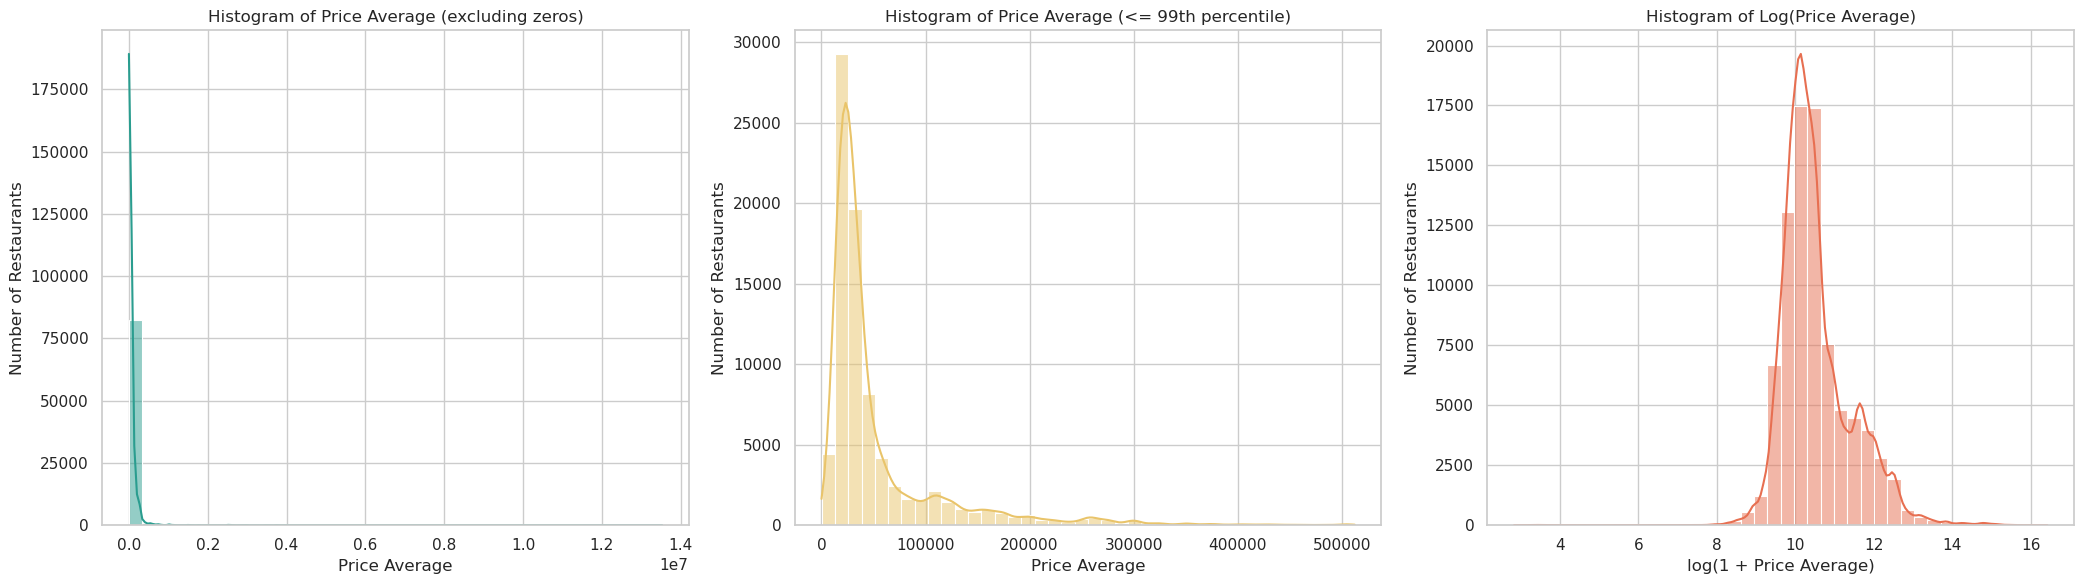

In [13]:
price_cols = ['PriceMin', 'PriceMax']

df['Price Average'] = df[price_cols].mean(axis=1)

df['Price Average No Zero'] = df[price_cols].replace(0, np.nan).mean(axis=1)

price_info = pd.DataFrame({
    'non_null': df[price_cols + ['Price Average', 'Price Average No Zero']].count(),
    'zero_count': [
        (df['PriceMin'] == 0).sum(),
        (df['PriceMax'] == 0).sum(),
        (df['Price Average'] == 0).sum(),
        (df['Price Average No Zero'] == 0).sum(),
    ],
    'mean': df[price_cols + ['Price Average', 'Price Average No Zero']].mean(),
    'median': df[price_cols + ['Price Average', 'Price Average No Zero']].median(),
    'min': df[price_cols + ['Price Average', 'Price Average No Zero']].min(),
    'max': df[price_cols + ['Price Average', 'Price Average No Zero']].max(),
})

print("=== PRICE SUMMARY ===")
display(price_info)

display(
    df[price_cols + ['Price Average', 'Price Average No Zero']]
    .describe()
)

price_clean = df['Price Average No Zero'].dropna().astype(float)

p99 = price_clean.quantile(0.99)
price_p99 = price_clean[price_clean <= p99]

print("99th percentile:", p99)
print("Rows after removing zero:", len(price_clean))
print("Rows after removing outliers:", len(price_p99))


fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.histplot(price_clean, bins=40, kde=True, color='#2a9d8f', ax=axes[0])
axes[0].set_title('Histogram of Price Average (excluding zeros)')
axes[0].set_xlabel('Price Average')
axes[0].set_ylabel('Number of Restaurants')

sns.histplot(price_p99, bins=40, kde=True, color='#e9c46a', ax=axes[1])
axes[1].set_title('Histogram of Price Average (<= 99th percentile)')
axes[1].set_xlabel('Price Average')
axes[1].set_ylabel('Number of Restaurants')

sns.histplot(np.log1p(price_clean.values), bins=40, kde=True, color='#e76f51', ax=axes[2])
axes[2].set_title('Histogram of Log(Price Average)')
axes[2].set_xlabel('log(1 + Price Average)')
axes[2].set_ylabel('Number of Restaurants')

plt.tight_layout()
plt.show()

## 8. Totalview distribution

,TotalView (raw),TotalView (clean)
count,95069.000000,94969.000000
mean,1965.929788,1967.999863
std,9922.282231,9927.299683
min,0.000000,1.000000
25%,43.000000,43.000000
50%,106.000000,106.000000
75%,415.000000,416.000000
95%,6832.200000,6837.000000
99%,45457.840000,45484.600000
max,489505.000000,489505.000000


99 percentile: 45484.59999999996


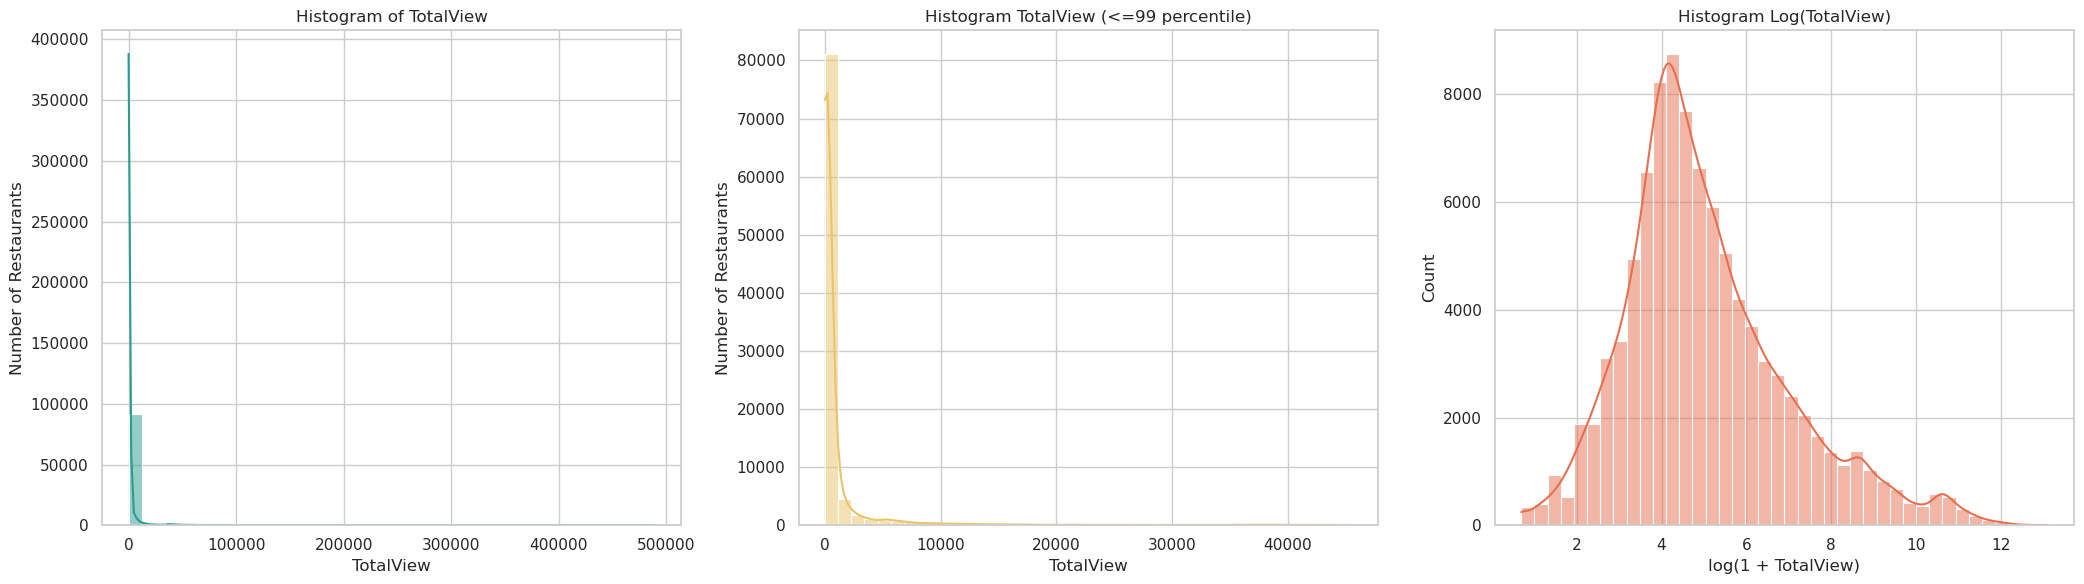

In [14]:
before = df['TotalView'].describe(percentiles=[0.25,0.5,0.75,0.95,0.99])

view_clean = df['TotalView'].replace(0, np.nan).dropna().astype(float)

after = view_clean.describe(percentiles=[0.25,0.5,0.75,0.95,0.99])

compare = pd.concat([before, after], axis=1)
compare.columns = ['TotalView (raw)', 'TotalView (clean)']

display(compare)

p99_view = view_clean.quantile(0.99)
view_p99 = view_clean[view_clean <= p99_view]

print("99 percentile:", p99_view)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.histplot(view_clean, bins=40, kde=True, color='#2a9d8f', ax=axes[0])
axes[0].set_title('Histogram of TotalView')
axes[0].set_xlabel('TotalView')
axes[0].set_ylabel('Number of Restaurants')

sns.histplot(view_p99, bins=40, kde=True, color='#e9c46a', ax=axes[1])
axes[1].set_title('Histogram TotalView (<=99 percentile)')
axes[1].set_xlabel('TotalView')
axes[1].set_ylabel('Number of Restaurants')

sns.histplot(np.log1p(view_clean), bins=40, kde=True, color='#e76f51', ax=axes[2])
axes[2].set_title('Histogram Log(TotalView)')
axes[2].set_xlabel('log(1 + TotalView)')

plt.tight_layout()
plt.show()

## 9. The relationship between Price and Totalview

,Price Average,TotalView
count,7.514100e+04,75141.000000
mean,6.403859e+04,2470.583303
std,1.851190e+05,11099.727404
min,1.600000e+01,1.000000
25%,2.000000e+04,66.000000
50%,3.000000e+04,162.000000
75%,5.250000e+04,640.000000
95%,2.000000e+05,9472.000000
99%,4.900000e+05,51338.600000
max,1.352950e+07,489505.000000


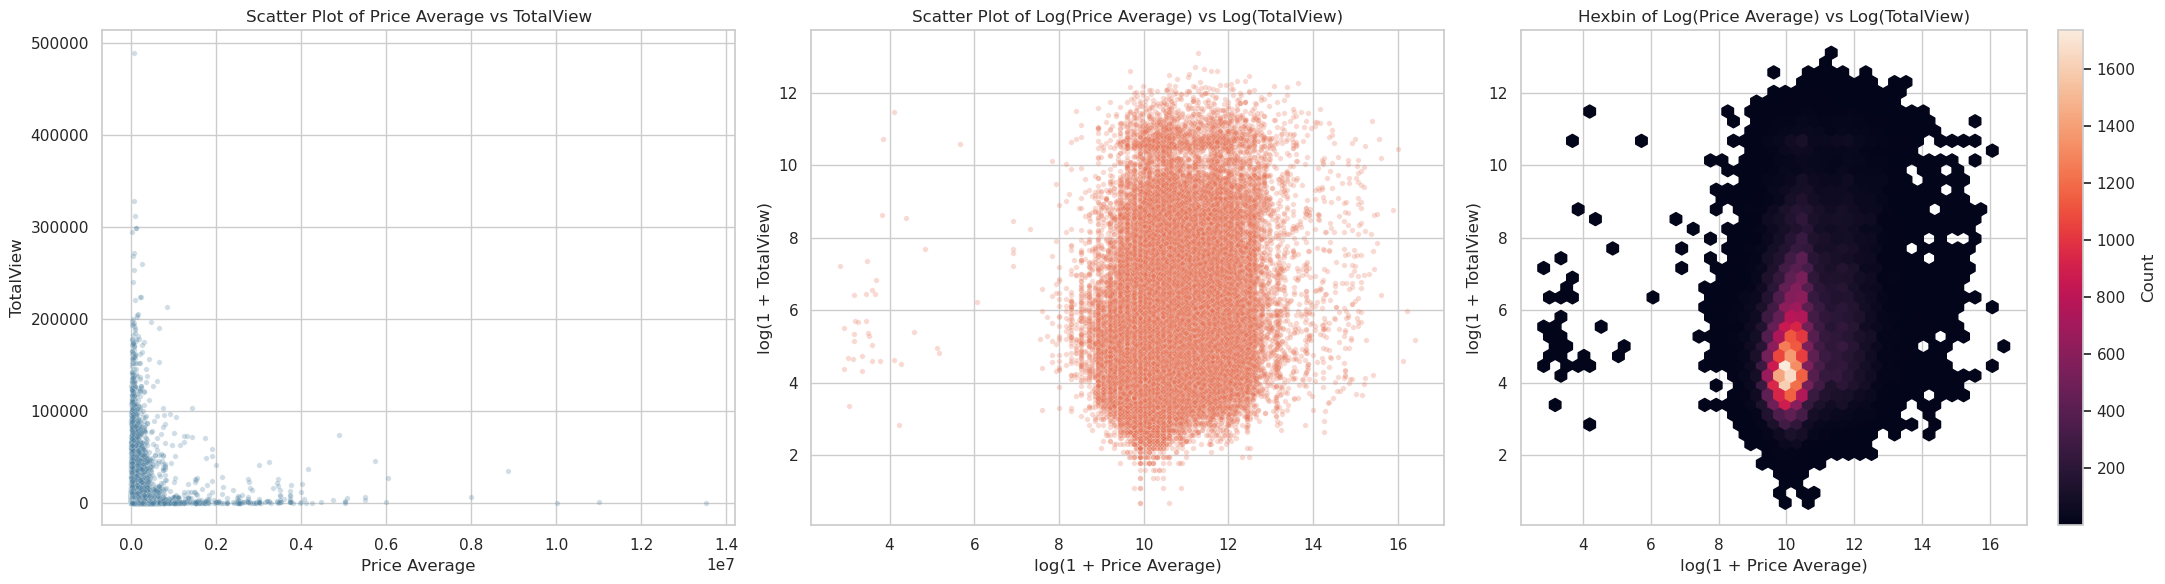

In [15]:
scatter_df = df[['Price Average No Zero', 'TotalView']].copy()
scatter_df = scatter_df.rename(columns={'Price Average No Zero': 'Price Average'})

scatter_df['Price Average'] = scatter_df['Price Average'].replace(0, np.nan)
scatter_df['TotalView'] = scatter_df['TotalView'].replace(0, np.nan)
scatter_df = scatter_df.dropna()

scatter_df['Price Average'] = scatter_df['Price Average'].astype(float)
scatter_df['TotalView'] = scatter_df['TotalView'].astype(float)

display(scatter_df.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

scatter_df['Log Price Average'] = np.log1p(scatter_df['Price Average'])
scatter_df['Log TotalView'] = np.log1p(scatter_df['TotalView'])


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(
    data=scatter_df,
    x='Price Average',
    y='TotalView',
    alpha=0.25,
    s=15,
    color='#457b9d',
    ax=axes[0]
)
axes[0].set_title('Scatter Plot of Price Average vs TotalView')
axes[0].set_xlabel('Price Average')
axes[0].set_ylabel('TotalView')

sns.scatterplot(
    data=scatter_df,
    x='Log Price Average',
    y='Log TotalView',
    alpha=0.25,
    s=15,
    color='#e76f51',
    ax=axes[1]
)
axes[1].set_title('Scatter Plot of Log(Price Average) vs Log(TotalView)')
axes[1].set_xlabel('log(1 + Price Average)')
axes[1].set_ylabel('log(1 + TotalView)')

hb = axes[2].hexbin(
    scatter_df['Log Price Average'],
    scatter_df['Log TotalView'],
    gridsize=40,
    mincnt=1
)
axes[2].set_title('Hexbin of Log(Price Average) vs Log(TotalView)')
axes[2].set_xlabel('log(1 + Price Average)')
axes[2].set_ylabel('log(1 + TotalView)')
fig.colorbar(hb, ax=axes[2], label='Count')

plt.tight_layout()
plt.show()

## 10. Correlation analysis between 5 rating 

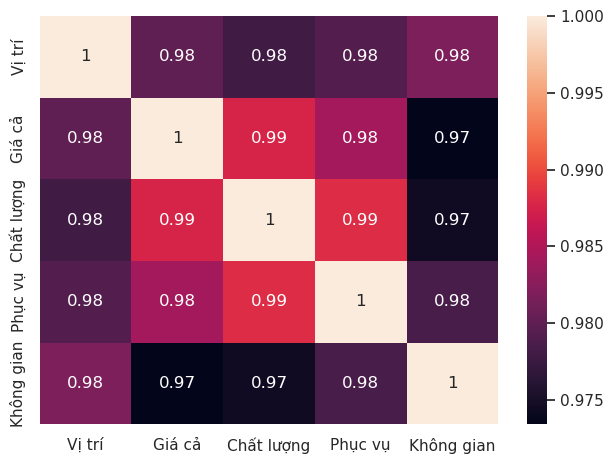

In [16]:
rating_cols = ['Vị trí', 'Giá cả', 'Chất lượng', 'Phục vụ', 'Không gian']

sns.heatmap(df[rating_cols].corr(), annot=True)
plt.tight_layout()
plt.show()

## 11. Average rating distribution

,Vị trí,Giá cả,Chất lượng,Phục vụ,Không gian,AvgRating5
count,107365.000000,107365.000000,107365.000000,107365.000000,107365.000000,107365.000000
mean,2.401864,2.427916,2.469742,2.397138,2.304441,2.400220
std,3.568767,3.641672,3.720431,3.612252,3.451194,3.570912
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.500000,6.400000,6.560000,6.240000,6.000000,6.520000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


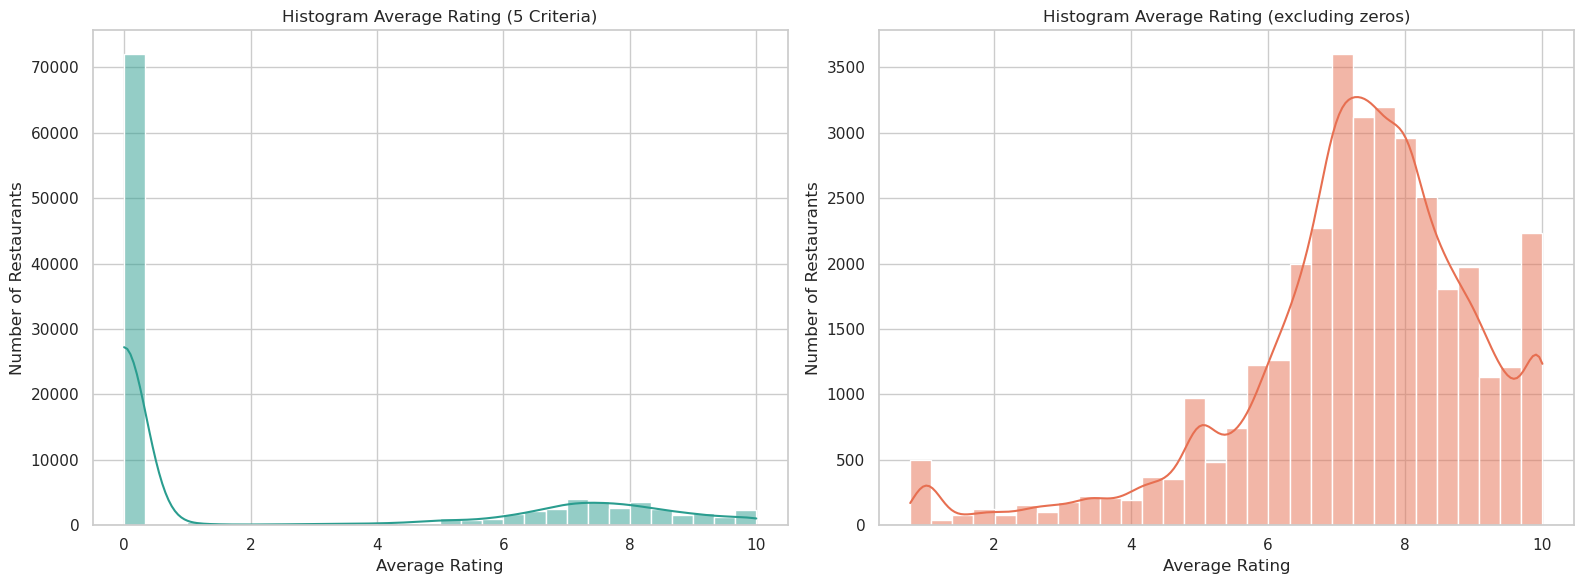

In [17]:
df['AvgRating5'] = df[rating_cols].mean(axis=1)
df['AvgRating5_NoZero'] = df[rating_cols].replace(0, pd.NA).mean(axis=1)

display(df[rating_cols + ['AvgRating5', 'AvgRating5_NoZero']].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['AvgRating5'], bins=30, kde=True, color='#2a9d8f', ax=axes[0])
axes[0].set_title('Histogram Average Rating (5 Criteria)')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Restaurants')

sns.histplot(df['AvgRating5_NoZero'].dropna(), bins=30, kde=True, color='#e76f51', ax=axes[1])
axes[1].set_title('Histogram Average Rating (excluding zeros)')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Number of Restaurants')

plt.tight_layout()
plt.show()


## 12. Delivery and Table Reservation Availability

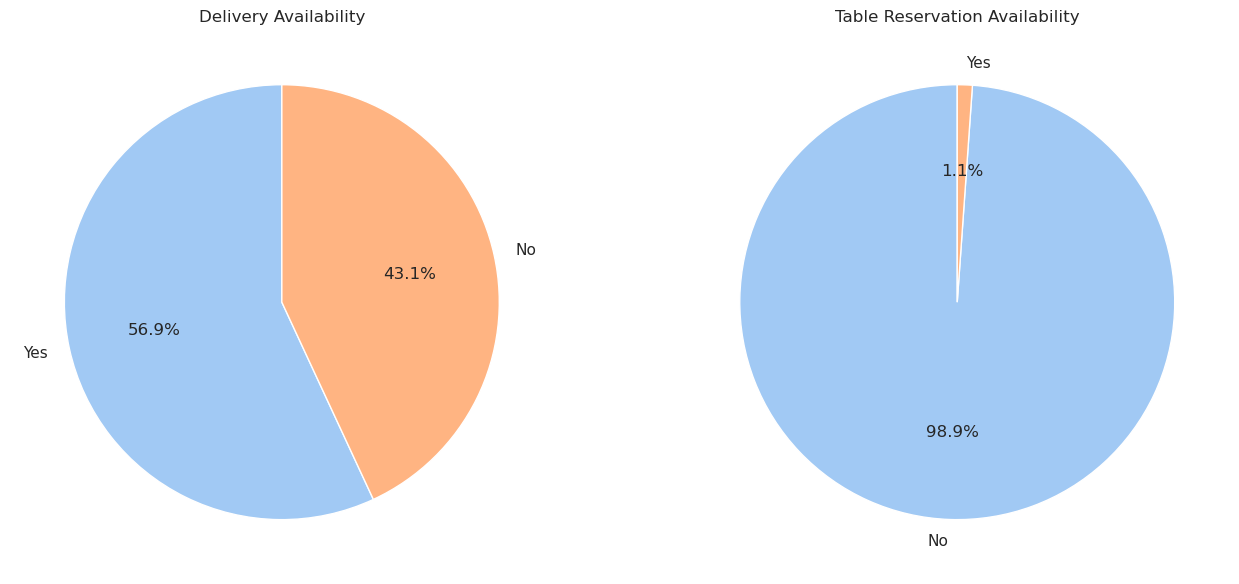

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ship_counts = df['Giao tận nơi'].map({1: 'Yes', 0: 'No'}).value_counts()
axes[0].pie(
    ship_counts.values,
    labels=ship_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel', len(ship_counts))
)
axes[0].set_title('Delivery Availability')

book_counts = df['Đặt bàn'].map({1: 'Yes', 0: 'No'}).value_counts()
axes[1].pie(
    book_counts.values,
    labels=book_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel', len(book_counts))
)
axes[1].set_title('Table Reservation Availability')

plt.tight_layout()
plt.show()


## 13. Analyzing the restaurant's schedule

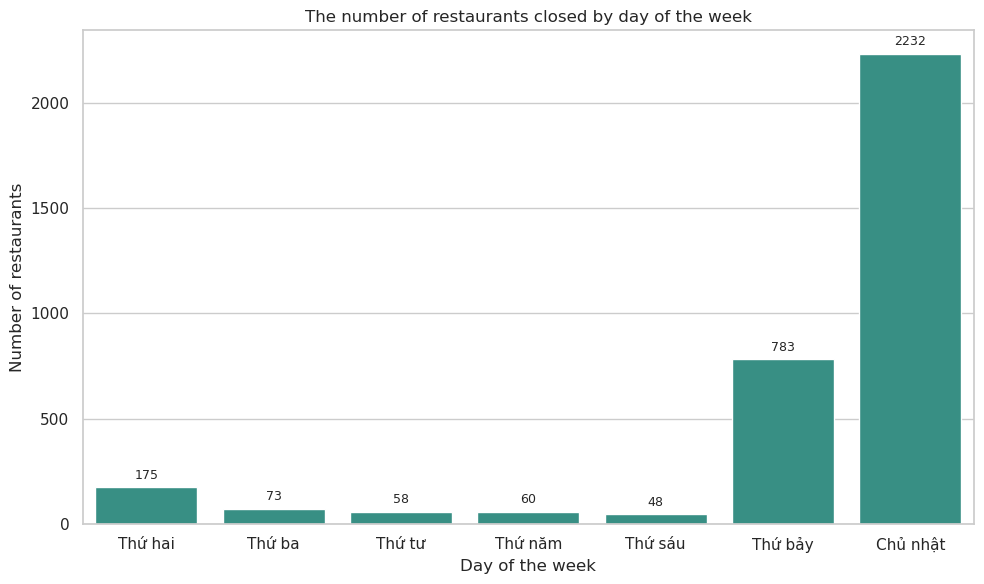

In [19]:
weekday_order = ['Thứ hai', 'Thứ ba', 'Thứ tư', 'Thứ năm', 'Thứ sáu', 'Thứ bảy', 'Chủ nhật']
dayoff_exploded = split_multivalue_column(df['Ngày nghỉ'])
dayoff_counts = dayoff_exploded.value_counts().reindex(weekday_order, fill_value=0)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=dayoff_counts.index, y=dayoff_counts.values, color='#2a9d8f')
add_value_labels(ax)
plt.title('The number of restaurants closed by day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Number of restaurants')
plt.tight_layout()
plt.show()

In [20]:
weekday_cols = ['Thứ hai', 'Thứ ba', 'Thứ tư', 'Thứ năm', 'Thứ sáu', 'Thứ bảy', 'Chủ nhật']

def split_dayoff_to_list(series):
    return (
        series.fillna('')
        .astype('string')
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
        .str.split(r'\s*\|\|\s*', regex=True)
        .apply(lambda x: [item.strip() for item in x if item.strip()])
    )

def active_opening_hours_for_day(df, day_col):
    day_off_lists = split_dayoff_to_list(df['Ngày nghỉ'])

    not_off_mask = ~day_off_lists.apply(lambda days: day_col in days)

    intervals = (
        df.loc[not_off_mask, day_col]
        .dropna()
        .astype('string')
        .str.strip()
    )

    intervals = intervals[intervals != '']
    return intervals


top_interval_by_day = []

for day in weekday_cols:
    intervals = active_opening_hours_for_day(df, day)
    counts = intervals.value_counts()

    if not counts.empty:
        top_interval_by_day.append({
            'Day': day,
            'Most Common Opening Time Interval': counts.index[0],
            'Number of Restaurants': int(counts.iloc[0]),
        })

top_interval_by_day_df = pd.DataFrame(top_interval_by_day)
display(top_interval_by_day_df)


,Day,Most Common Opening Time Interval,Number of Restaurants
0,Thứ hai,"('09:00', '22:00')",8479
1,Thứ ba,"('09:00', '22:00')",8516
2,Thứ tư,"('09:00', '22:00')",8569
3,Thứ năm,"('09:00', '22:00')",8553
4,Thứ sáu,"('09:00', '22:00')",8544
5,Thứ bảy,"('09:00', '22:00')",8071
6,Chủ nhật,"('09:00', '22:00')",7845


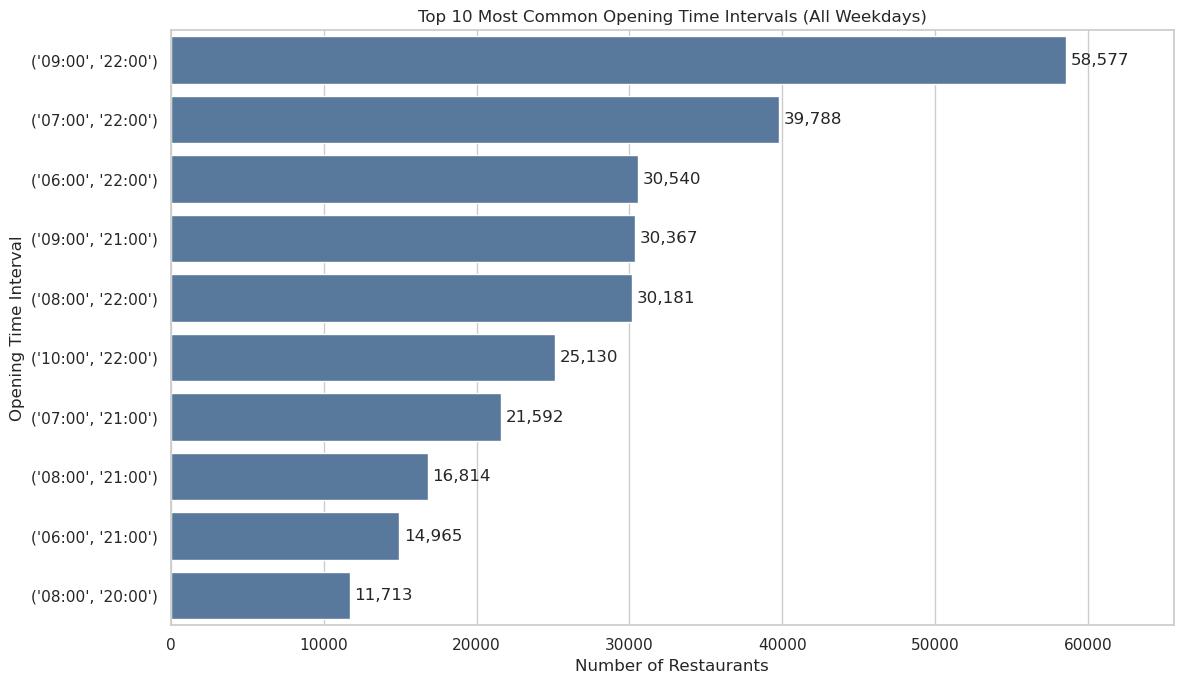

In [21]:
weekday_cols = ['Thứ hai', 'Thứ ba', 'Thứ tư', 'Thứ năm', 'Thứ sáu', 'Thứ bảy', 'Chủ nhật']

def get_all_active_opening_intervals(df, weekday_cols):
    day_off_lists = split_dayoff_to_list(df['Ngày nghỉ'])
    all_intervals = []

    for day in weekday_cols:
        not_off_mask = ~day_off_lists.apply(lambda days: day in days)

        intervals = (
            df.loc[not_off_mask, day]
            .dropna()
            .astype('string')
            .str.strip()
        )
        intervals = intervals[intervals != '']

        all_intervals.append(intervals)

    return pd.concat(all_intervals, ignore_index=True)

def add_value_labels_horizontal(ax, spacing=300):
    max_width = 0

    for container in ax.containers:
        for bar in container:
            w = bar.get_width()
            y = bar.get_y() + bar.get_height() / 2
            max_width = max(max_width, w)

            ax.text(
                w + spacing,
                y,
                f'{int(w):,}',
                va='center',
                ha='left'
            )

    ax.set_xlim(0, max_width * 1.12)

all_intervals = get_all_active_opening_intervals(df, weekday_cols)
top_10_intervals = all_intervals.value_counts().head(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=top_10_intervals.values,
    y=top_10_intervals.index,
    color='#4e79a7'
)

add_value_labels_horizontal(ax, spacing=300)

plt.title('Top 10 Most Common Opening Time Intervals (All Weekdays)')
plt.xlabel('Number of Restaurants')
plt.ylabel('Opening Time Interval')
plt.tight_layout()
plt.show()

## 14. Restaurant's Sentiments

,count
SentimentLabel,
Neutral/Tie,74504
Positive,25837
Negative,7024


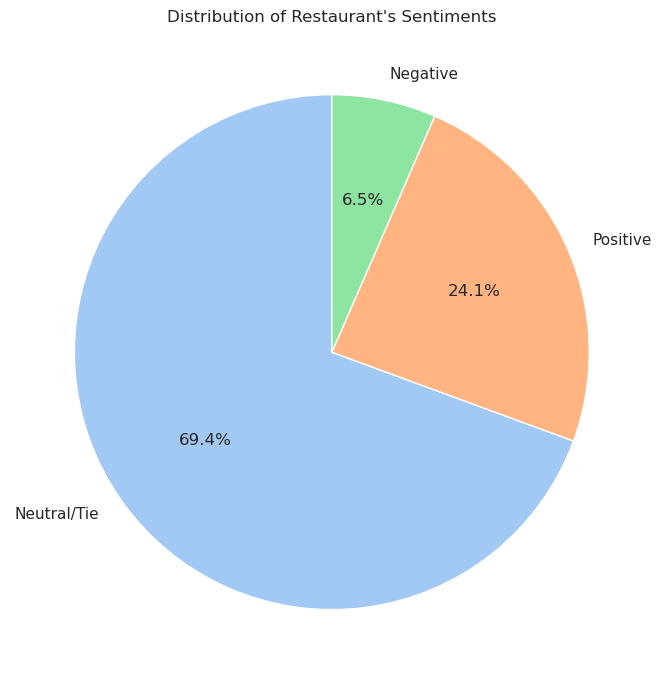

In [22]:
df['Positive'] = df['Excellent'] + df['Good']
df['Negative'] = df['Average'] + df['Bad']

df['SentimentLabel'] = 'Neutral/Tie'
df.loc[df['Positive'] > df['Negative'], 'SentimentLabel'] = 'Positive'
df.loc[df['Positive'] < df['Negative'], 'SentimentLabel'] = 'Negative'

sentiment_counts = df['SentimentLabel'].value_counts()
display(sentiment_counts.to_frame('count'))

plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel', len(sentiment_counts))
)
plt.title("Distribution of Restaurant's Sentiments")
plt.tight_layout()
plt.show()
